In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
india_csv = r"C:\Users\ACER\Desktop\vs code\proj\india_job_market_2024_2026.csv"

df = pd.read_csv(india_csv)

df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,10/31/2025
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,5/19/2025
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,8/21/2024
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,3/18/2026
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,10/25/2024


In [3]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(5000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   str    
 1   Job_Title           5000 non-null   str    
 2   Company             5000 non-null   str    
 3   Company_Type        5000 non-null   str    
 4   Industry            5000 non-null   str    
 5   City                5000 non-null   str    
 6   Location_Tier       5000 non-null   str    
 7   Experience_Level    5000 non-null   str    
 8   Job_Type            5000 non-null   str    
 9   Work_Mode           5000 non-null   str    
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   str    
 12  Education_Required  5000 non-null   str    
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

In [4]:
df.describe()

,Salary_LPA,Openings,Applicants,Company_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.829440,3.642600,302.072000,3.698420
std,18.136741,4.046942,363.989613,0.424994
min,0.800000,1.000000,14.000000,2.500000
25%,6.800000,1.000000,99.000000,3.400000
50%,13.600000,2.000000,185.000000,3.800000
75%,25.600000,3.000000,321.000000,4.100000
max,115.400000,20.000000,2387.000000,4.300000


In [5]:
if 'Job_ID' in df.columns:
    df.drop('Job_ID', axis=1, inplace=True)

if 'Date_Posted' in df.columns:
    df.drop('Date_Posted', axis=1, inplace=True)

df.head()

,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating
0,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0
1,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0
2,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6
3,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5
4,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9


In [6]:
df_visual = df.copy()

In [7]:
label_encoders = {}

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:

    le = LabelEncoder()

    df[column] = le.fit_transform(df[column].astype(str))

    label_encoders[column] = le

df.head()

C:\Users\ACER\AppData\Local\Temp\ipykernel_18324\1025166245.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating
0,1,47,1,9,16,0,4,1,2,30.9,1926,4,3,276,4.0
1,23,15,0,9,12,2,4,1,0,58.6,4036,2,3,325,4.0
2,4,21,2,4,16,0,4,1,2,18.4,1542,6,5,559,3.6
3,7,20,3,9,13,1,3,1,0,21.7,2667,3,3,184,3.5
4,22,38,1,4,16,0,1,1,2,8.0,1002,6,1,64,3.9


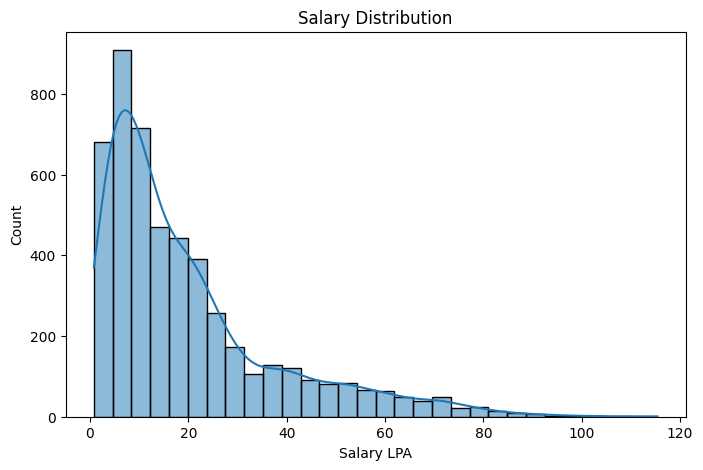

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Salary_LPA'], bins=30, kde=True)

plt.title("Salary Distribution")

plt.xlabel("Salary LPA")

plt.ylabel("Count")

plt.show()

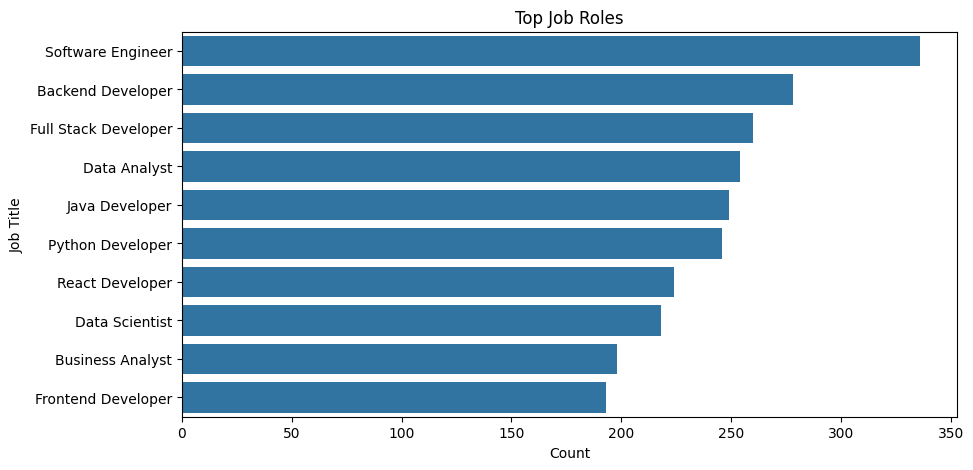

In [9]:
top_jobs = df_visual['Job_Title'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top Job Roles")

plt.xlabel("Count")

plt.ylabel("Job Title")

plt.show()

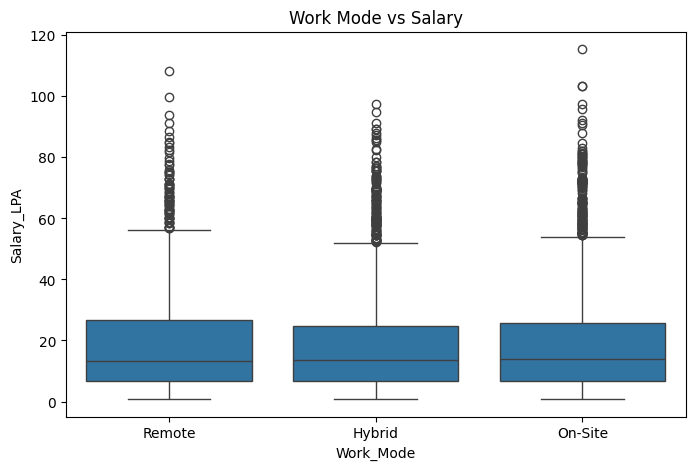

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_visual['Work_Mode'],
    y=df_visual['Salary_LPA']
)

plt.title("Work Mode vs Salary")

plt.show()

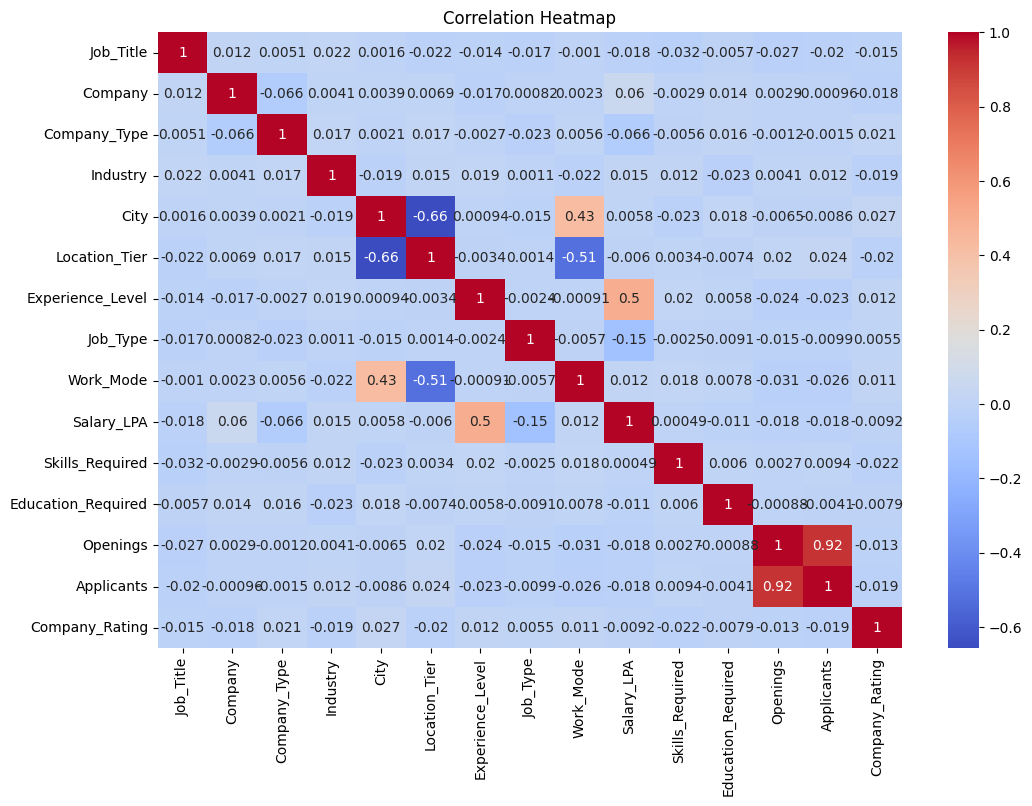

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
X = df.drop('Salary_LPA', axis=1)

y = df['Salary_LPA']

print(X.columns)

Index(['Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Skills_Required', 'Education_Required', 'Openings', 'Applicants',
       'Company_Rating'],
      dtype='str')


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(4000, 14)
(1000, 14)


In [14]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [15]:
y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))

print("RMSE :", round(rmse, 2))

print("R2 Score :", round(r2, 2))

MAE : 2.86
RMSE : 4.6
R2 Score : 0.93


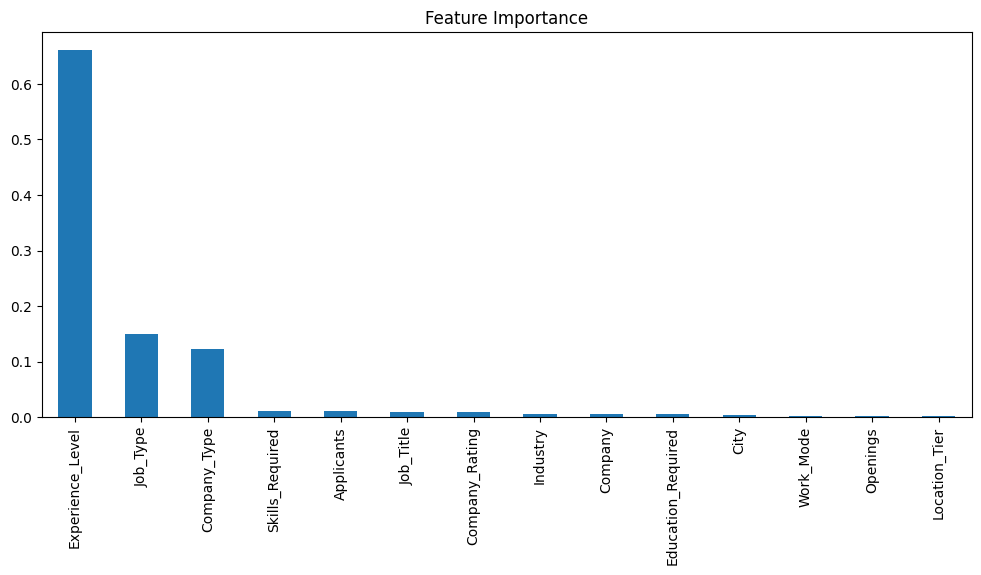

In [17]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Feature Importance")

plt.show()

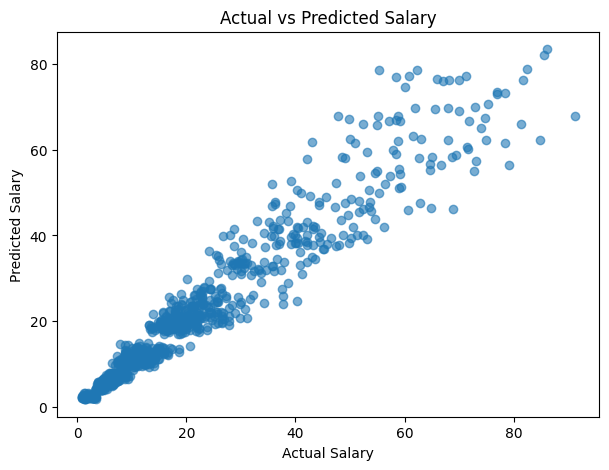

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

In [19]:
joblib.dump(model, 'job_salary_model.pkl')

joblib.dump(label_encoders, 'label_encoders.pkl')

joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Files Saved Successfully")

Files Saved Successfully
